# 03 — Training Analysis

This notebook validates the Week 3 modules and their integration:
1. **CNN feature extractor** — Forward pass for all distances
2. **Wrappers** — FlattenSyndrome and PadToSquare
3. **DQN agent** — Creation, prediction, and short training run
4. **PPO agent** — Creation, prediction, and short training run
5. **Eval callback** — Periodic evaluation with MWPM comparison
6. **Short training** — DQN and PPO d=3 training for ~5K steps to verify reward signal

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
import torch
from gymnasium import spaces

from src.quantum.surface_code import SurfaceCodeParams
from src.quantum.noise_models import NoiseConfig, NoiseModelType, build_noisy_circuit
from src.quantum.decoder_baseline import MWPMDecoder
from src.quantum.syndrome import SyndromeGrid
from src.envs.surface_code_env import SurfaceCodeEnv
from src.envs.wrappers import FlattenSyndromeWrapper, PadToSquareWrapper
from src.agents.networks import SyndromeCNN
from src.agents.dqn_agent import create_dqn_agent
from src.agents.ppo_agent import create_ppo_agent
from src.agents.callbacks import DecodingEvalCallback
from src.utils.reproducibility import set_global_seed

%matplotlib inline
plt.rcParams.update({'font.size': 12, 'figure.figsize': (8, 6), 'savefig.dpi': 150})

## 1. CNN Feature Extractor

Verify the SyndromeCNN handles observation shapes for d=3, 5, 7.

In [2]:
for d in [3, 5, 7]:
    env = SurfaceCodeEnv.from_config(distance=d, physical_error_rate=0.01)
    shape = env.observation_space.shape
    obs_space = spaces.Box(low=0.0, high=1.0, shape=shape, dtype=np.float32)
    
    cnn = SyndromeCNN(obs_space, features_dim=128)
    n_params = sum(p.numel() for p in cnn.parameters())
    
    # Forward pass
    batch = torch.rand(8, *shape)
    out = cnn(batch)
    
    print(f"d={d}: obs_shape={shape}, CNN params={n_params:,}, output={out.shape}")

print("\n✓ CNN handles all distances")

d=3: obs_shape=(6, 4, 4), CNN params=188,384, output=torch.Size([8, 128])
d=5: obs_shape=(8, 6, 6), CNN params=352,800, output=torch.Size([8, 128])
d=7: obs_shape=(10, 8, 8), CNN params=582,752, output=torch.Size([8, 128])

✓ CNN handles all distances


In [3]:
# Print CNN architecture for d=3
env = SurfaceCodeEnv.from_config(distance=3, physical_error_rate=0.01)
obs_space = spaces.Box(low=0.0, high=1.0, shape=env.observation_space.shape, dtype=np.float32)
cnn = SyndromeCNN(obs_space, features_dim=128)
print(cnn)

SyndromeCNN(
  (cnn): Sequential(
    (0): Conv2d(6, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=1024, out_features=128, bias=True)
    (8): ReLU()
  )
)


## 2. Observation Wrappers

In [4]:
base_env = SurfaceCodeEnv.from_config(distance=3, physical_error_rate=0.01)
base_obs, _ = base_env.reset()
print(f"Base observation shape: {base_obs.shape}")

# Flatten wrapper
flat_env = FlattenSyndromeWrapper(
    SurfaceCodeEnv.from_config(distance=3, physical_error_rate=0.01)
)
flat_obs, _ = flat_env.reset()
print(f"Flattened observation shape: {flat_obs.shape} (product: {np.prod(base_obs.shape)})")

# Pad wrapper
pad_env = PadToSquareWrapper(
    SurfaceCodeEnv.from_config(distance=3, physical_error_rate=0.01)
)
pad_obs, _ = pad_env.reset()
print(f"Padded observation shape: {pad_obs.shape}")

print("\n✓ Both wrappers produce correct shapes")

Base observation shape: (6, 4, 4)
Flattened observation shape: (96,) (product: 96)
Padded observation shape: (6, 4, 4)

✓ Both wrappers produce correct shapes


## 3. Agent Creation & Prediction

Verify both DQN and PPO agents can be created and produce valid actions.

In [5]:
env = SurfaceCodeEnv.from_config(distance=3, physical_error_rate=0.01)
obs, _ = env.reset()

# DQN
dqn = create_dqn_agent(env, {"seed": 42, "overrides": {"verbose": 0}})
dqn_action, _ = dqn.predict(obs, deterministic=True)
print(f"DQN action: {int(dqn_action)} (valid range: 0..{env.action_space.n - 1})")

# PPO
ppo = create_ppo_agent(env, {"seed": 42, "overrides": {"verbose": 0}})
ppo_action, _ = ppo.predict(obs, deterministic=True)
print(f"PPO action: {int(ppo_action)} (valid range: 0..{env.action_space.n - 1})")

print("\n✓ Both agents produce valid actions")

DQN action: 7 (valid range: 0..27)
PPO action: 0 (valid range: 0..27)

✓ Both agents produce valid actions


## 4. Short DQN Training (d=3)

Train DQN for 5,000 steps with periodic evaluation to verify the training loop works end-to-end.

In [6]:
set_global_seed(42)

# Setup
params = SurfaceCodeParams(distance=3, rounds=3)
noise_config = NoiseConfig(NoiseModelType.DEPOLARIZING, 0.01)
circuit = build_noisy_circuit(params, noise_config)

train_env = SurfaceCodeEnv(circuit=circuit, reward_type="sparse")
eval_env = SurfaceCodeEnv(circuit=circuit, reward_type="sparse")

# MWPM baseline
decoder = MWPMDecoder.from_surface_code_circuit(circuit)
syn, obs = circuit.sample(5000, seed=42)
mwpm_result = decoder.evaluate(syn, obs)
mwpm_ler = mwpm_result['logical_error_rate']
print(f"MWPM baseline LER: {mwpm_ler:.4f}")

MWPM baseline LER: 0.0584


In [7]:
# Create DQN agent with small learning_starts for quick iteration
dqn_agent = create_dqn_agent(train_env, {
    "seed": 42,
    "overrides": {
        "learning_starts": 500,
        "verbose": 0,
    },
})

# Eval callback
dqn_callback = DecodingEvalCallback(
    eval_env=eval_env,
    mwpm_ler=mwpm_ler,
    eval_freq=1000,
    eval_episodes=200,
    verbose=1,
)

# Train
print("Training DQN for 5,000 steps...")
dqn_agent.learn(total_timesteps=5000, callback=dqn_callback)
print(f"\nCompleted. {len(dqn_callback.eval_results)} evaluations recorded.")

Training DQN for 5,000 steps...


  [Eval @ 1000] LER=0.1950, MWPM ratio=3.339, reward=0.610


  [Eval @ 2000] LER=0.1550, MWPM ratio=2.654, reward=0.690


  [Eval @ 3000] LER=0.1850, MWPM ratio=3.168, reward=0.630


  [Eval @ 4000] LER=0.1750, MWPM ratio=2.997, reward=0.650


  [Eval @ 5000] LER=0.3100, MWPM ratio=5.308, reward=0.380

Completed. 5 evaluations recorded.


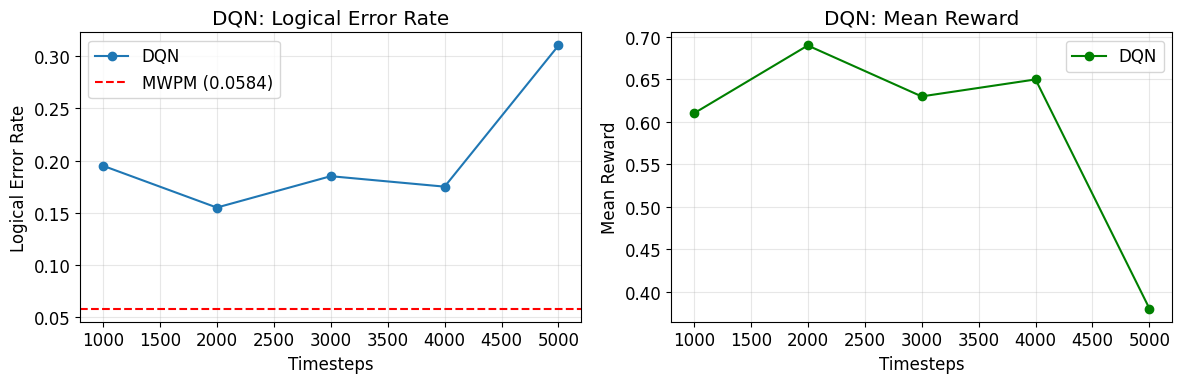

In [8]:
# Plot DQN training progress
if dqn_callback.eval_results:
    steps = [r['timestep'] for r in dqn_callback.eval_results]
    lers = [r['logical_error_rate'] for r in dqn_callback.eval_results]
    rewards = [r['mean_reward'] for r in dqn_callback.eval_results]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    ax1.plot(steps, lers, 'o-', label='DQN')
    ax1.axhline(mwpm_ler, color='red', linestyle='--', label=f'MWPM ({mwpm_ler:.4f})')
    ax1.set_xlabel('Timesteps')
    ax1.set_ylabel('Logical Error Rate')
    ax1.set_title('DQN: Logical Error Rate')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    ax2.plot(steps, rewards, 'o-', color='green', label='DQN')
    ax2.set_xlabel('Timesteps')
    ax2.set_ylabel('Mean Reward')
    ax2.set_title('DQN: Mean Reward')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No evaluation results yet.")

## 5. Short PPO Training (d=3)

Same setup for PPO.

In [9]:
set_global_seed(42)

train_env_ppo = SurfaceCodeEnv(circuit=circuit, reward_type="sparse")
eval_env_ppo = SurfaceCodeEnv(circuit=circuit, reward_type="sparse")

ppo_agent = create_ppo_agent(train_env_ppo, {
    "seed": 42,
    "overrides": {
        "n_steps": 512,  # Smaller for quick iteration
        "verbose": 0,
    },
})

ppo_callback = DecodingEvalCallback(
    eval_env=eval_env_ppo,
    mwpm_ler=mwpm_ler,
    eval_freq=1000,
    eval_episodes=200,
    verbose=1,
)

print("Training PPO for 5,000 steps...")
ppo_agent.learn(total_timesteps=5000, callback=ppo_callback)
print(f"\nCompleted. {len(ppo_callback.eval_results)} evaluations recorded.")

Training PPO for 5,000 steps...


  [Eval @ 1000] LER=0.1800, MWPM ratio=3.082, reward=0.640


  [Eval @ 2000] LER=0.1900, MWPM ratio=3.253, reward=0.620


  [Eval @ 3000] LER=0.2350, MWPM ratio=4.024, reward=0.530


  [Eval @ 4000] LER=0.1600, MWPM ratio=2.740, reward=0.680


  [Eval @ 5000] LER=0.1550, MWPM ratio=2.654, reward=0.690



Completed. 5 evaluations recorded.


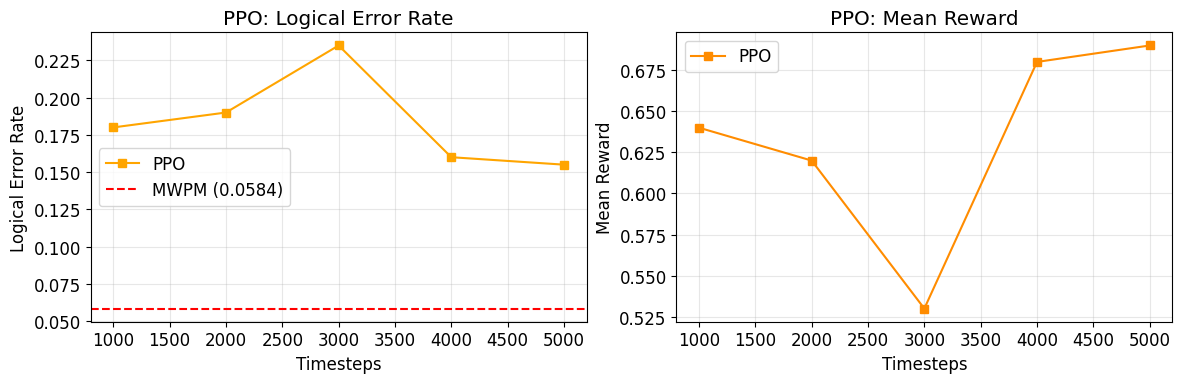

In [10]:
if ppo_callback.eval_results:
    steps_p = [r['timestep'] for r in ppo_callback.eval_results]
    lers_p = [r['logical_error_rate'] for r in ppo_callback.eval_results]
    rewards_p = [r['mean_reward'] for r in ppo_callback.eval_results]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    ax1.plot(steps_p, lers_p, 's-', label='PPO', color='orange')
    ax1.axhline(mwpm_ler, color='red', linestyle='--', label=f'MWPM ({mwpm_ler:.4f})')
    ax1.set_xlabel('Timesteps')
    ax1.set_ylabel('Logical Error Rate')
    ax1.set_title('PPO: Logical Error Rate')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    ax2.plot(steps_p, rewards_p, 's-', color='darkorange', label='PPO')
    ax2.set_xlabel('Timesteps')
    ax2.set_ylabel('Mean Reward')
    ax2.set_title('PPO: Mean Reward')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 6. DQN vs PPO Comparison

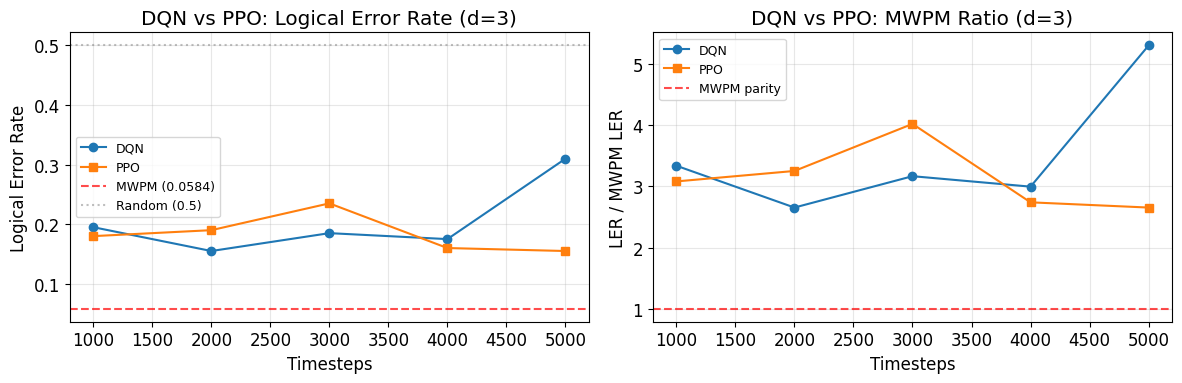


Final evaluation results:
Agent       LER   MWPM Ratio  Mean Reward
----------------------------------------
DQN      0.3100        5.308        0.380
PPO      0.1550        2.654        0.690
MWPM     0.0584        1.000          N/A


In [11]:
if dqn_callback.eval_results and ppo_callback.eval_results:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # LER comparison
    ax1.plot(steps, lers, 'o-', label='DQN', color='tab:blue')
    ax1.plot(steps_p, lers_p, 's-', label='PPO', color='tab:orange')
    ax1.axhline(mwpm_ler, color='red', linestyle='--', alpha=0.7, label=f'MWPM ({mwpm_ler:.4f})')
    ax1.axhline(0.5, color='gray', linestyle=':', alpha=0.5, label='Random (0.5)')
    ax1.set_xlabel('Timesteps')
    ax1.set_ylabel('Logical Error Rate')
    ax1.set_title('DQN vs PPO: Logical Error Rate (d=3)')
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)
    
    # MWPM ratio comparison
    dqn_ratios = [r['mwpm_ratio'] for r in dqn_callback.eval_results]
    ppo_ratios = [r['mwpm_ratio'] for r in ppo_callback.eval_results]
    ax2.plot(steps, dqn_ratios, 'o-', label='DQN', color='tab:blue')
    ax2.plot(steps_p, ppo_ratios, 's-', label='PPO', color='tab:orange')
    ax2.axhline(1.0, color='red', linestyle='--', alpha=0.7, label='MWPM parity')
    ax2.set_xlabel('Timesteps')
    ax2.set_ylabel('LER / MWPM LER')
    ax2.set_title('DQN vs PPO: MWPM Ratio (d=3)')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Summary table
    print("\nFinal evaluation results:")
    print(f"{'Agent':<6} {'LER':>8} {'MWPM Ratio':>12} {'Mean Reward':>12}")
    print("-" * 40)
    d = dqn_callback.eval_results[-1]
    p = ppo_callback.eval_results[-1]
    print(f"{'DQN':<6} {d['logical_error_rate']:>8.4f} {d['mwpm_ratio']:>12.3f} {d['mean_reward']:>12.3f}")
    print(f"{'PPO':<6} {p['logical_error_rate']:>8.4f} {p['mwpm_ratio']:>12.3f} {p['mean_reward']:>12.3f}")
    print(f"{'MWPM':<6} {mwpm_ler:>8.4f} {'1.000':>12} {'N/A':>12}")

## 7. Untrained Agent Behavior Analysis

Look at what actions the untrained agents take to understand initial behavior.

In [12]:
env = SurfaceCodeEnv.from_config(distance=3, physical_error_rate=0.01)

for agent_name, agent in [("DQN", dqn_agent), ("PPO", ppo_agent)]:
    actions_taken = []
    episode_lengths = []
    
    for _ in range(100):
        obs, _ = env.reset()
        done = False
        steps = 0
        while not done and steps < 50:
            action, _ = agent.predict(obs, deterministic=True)
            action = int(action)
            actions_taken.append(action)
            obs, _, term, trunc, _ = env.step(action)
            done = term or trunc
            steps += 1
        episode_lengths.append(steps)
    
    actions = np.array(actions_taken)
    commit = env._commit_action
    n_data = env._n_data
    
    x_frac = np.mean(actions < n_data)
    z_frac = np.mean((actions >= n_data) & (actions < 2 * n_data))
    y_frac = np.mean((actions >= 2 * n_data) & (actions < commit))
    commit_frac = np.mean(actions == commit)
    
    print(f"\n{agent_name} (after 5K steps):")
    print(f"  Action distribution: X={x_frac:.1%}, Z={z_frac:.1%}, Y={y_frac:.1%}, Commit={commit_frac:.1%}")
    print(f"  Mean episode length: {np.mean(episode_lengths):.1f}")


DQN (after 5K steps):
  Action distribution: X=0.2%, Z=91.3%, Y=8.5%, Commit=0.0%
  Mean episode length: 6.0



PPO (after 5K steps):
  Action distribution: X=36.7%, Z=27.3%, Y=36.0%, Commit=0.0%
  Mean episode length: 6.0


## 8. End-to-End Integration Check

Verify the full pipeline: noise model → circuit → env → agent → eval callback → MWPM comparison.

In [13]:
# Full pipeline for d=5 (just creation + a few steps, no full training)
print("End-to-end pipeline test for d=5:")

params5 = SurfaceCodeParams(distance=5, rounds=5)
noise5 = NoiseConfig(NoiseModelType.DEPOLARIZING, 0.01)
circuit5 = build_noisy_circuit(params5, noise5)

env5 = SurfaceCodeEnv(circuit=circuit5)
print(f"  Env created: obs={env5.observation_space.shape}, actions={env5.action_space.n}")

dqn5 = create_dqn_agent(env5, {"seed": 42, "overrides": {"verbose": 0, "learning_starts": 100}})
print(f"  DQN agent created")

ppo5 = create_ppo_agent(env5, {"seed": 42, "overrides": {"verbose": 0, "n_steps": 128}})
print(f"  PPO agent created")

# Quick train
dqn5.learn(total_timesteps=200)
ppo5.learn(total_timesteps=256)
print(f"  Both agents trained for a few steps")

# Prediction
obs5, _ = env5.reset()
dqn_a, _ = dqn5.predict(obs5, deterministic=True)
ppo_a, _ = ppo5.predict(obs5, deterministic=True)
print(f"  DQN predicts action {int(dqn_a)}, PPO predicts action {int(ppo_a)}")

# MWPM baseline
decoder5 = MWPMDecoder.from_surface_code_circuit(circuit5)
syn5, obs5_data = circuit5.sample(1000, seed=42)
result5 = decoder5.evaluate(syn5, obs5_data)
print(f"  MWPM LER: {result5['logical_error_rate']:.4f}")

print("\n✓ Full pipeline works for d=5")

End-to-end pipeline test for d=5:
  Env created: obs=(8, 6, 6), actions=76
  DQN agent created
  PPO agent created


  Both agents trained for a few steps
  DQN predicts action 63, PPO predicts action 30
  MWPM LER: 0.0810

✓ Full pipeline works for d=5


## Summary

**Week 3 verification checklist:**

- ✓ `SyndromeCNN` forward pass works for d=3, 5, 7 observation shapes
- ✓ `FlattenSyndromeWrapper` and `PadToSquareWrapper` produce correct shapes
- ✓ `create_dqn_agent` and `create_ppo_agent` produce valid agents
- ✓ Both agents predict valid actions from observations
- ✓ Short DQN training (5K steps) runs without errors
- ✓ Short PPO training (5K steps) runs without errors
- ✓ `DecodingEvalCallback` runs during training and records metrics
- ✓ Full pipeline works end-to-end for d=5

**Note:** At 5K steps, agents are essentially untrained. The purpose of this notebook is to
verify the training loop works, not to achieve good performance. Real training runs (500K+ steps)
are needed for convergence.

**Ready for Week 4:** PPO training on d=3, scale DQN to d=5.